# Run inference
Ref: http://trillium.tech/ml4floods/content/ml4ops/HOWTO_Run_Inference_on_new_data.html

In [1]:
import sys, os
from pathlib import Path
import importlib
from models import flooding_model

## Step 1: Get config

In [2]:
from ml4floods.models.config_setup import get_default_config

experiment_name = "WFV1_unet"
prod_dev = "2_PROD"

# config_fp = "train_models/training_flooding/config_rgbnir.json"
config_fp = "/home/trongan93/thoailt/code/swrnet/train_models/training_flooding_bgri/config_irirnir_worldflood_model_1_epoch_2_adaptive_gamma_alpha_0_001.json"

config = get_default_config(config_fp)
config.data_params.data_params='ml4cc_data_lake'

# The max_tile_size param controls the max size of patches that are fed to the NN. If you're in a memory contrained environment set this value to 128
# config["model_params"]["max_tile_size"] = 128

Loaded Config for experiment:  training_flooding_bgri
{   'data_params': {   'batch_size': 128,
                       'bucket_id': '',
                       'channel_configuration': 'bgri',
                       'download': {'test': True, 'train': True, 'val': True},
                       'filter_windows': {   'apply': False,
                                             'threshold_clouds': 0.5,
                                             'version': 'v1'},
                       'input_folder': 'S2',
                       'loader_type': 'local',
                       'num_workers': 24,
                       'path_to_splits': '/mnt/d/Flooding/worldfloods_v1_0',
                       'target_folder': 'gt',
                       'test_transformation': {'normalize': True},
                       'train_test_split_file': '/mnt/d/Flooding/train_test_split_local.json',
                       'train_transformation': {'normalize': True},
                       'window_size': [256, 256]

## Step 2: Load pre-trained model

In [3]:
from pytorch_lightning.utilities.cloud_io import load
from models.flooding_model import WorldFloodsModel
importlib.reload(flooding_model)

model = WorldFloodsModel(config.model_params)
# path_to_models = os.path.join(config.model_params.model_folder,config.experiment_name, "model_rgbnir.pt").replace("\\","/")
path_to_models = os.path.join(config.model_params.model_folder,config.experiment_name, "/home/trongan93/thoailt/code/swrnet/train_models/training_flooding_bgri/model_irirnir_worldflood_model_1_epoch_2_adaptive_gamma_alpha_0_001.pt").replace("\\","/")

print(path_to_models)
model.load_state_dict(load(path_to_models))
model

model.eval()
model.to("cuda") # comment this line if your machine does not have GPU

/home/trongan93/thoailt/code/swrnet/train_models/training_flooding_bgri/model_irirnir_worldflood_model_1_epoch_2_adaptive_gamma_alpha_0_001.pt


/home/trongan93/anaconda3/envs/swr/lib/python3.8/site-packages/pytorch_lightning/utilities/cloud_io.py:41: LightningDeprecationWarning: `pytorch_lightning.utilities.cloud_io.load` has been deprecated in v1.8.0 and will be removed in v1.10.0. This function is internal but you can copy over its implementation.
  rank_zero_deprecation(
/home/trongan93/anaconda3/envs/swr/lib/python3.8/site-packages/lightning_lite/utilities/cloud_io.py:48: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via t

WorldFloodsModel(
  (network): SimpleUNet(
    (dconv_down1): Sequential(
      (0): Conv2d(4, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
    (dconv_down2): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
    (dconv_down3): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
    (dconv_down4): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1),

In [4]:
# from ml4floods.models.model_setup import get_model_inference_function
from models.inference import get_model_inference_function

inference_function = get_model_inference_function(model, config, apply_normalization=True)

Getting model inference function
Max tile size: 256


## Step 3: Helper functions for plotting and reading some demo data

In [5]:
import rasterio
import numpy as np
from rasterio import plot as rasterioplt
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.patches as mpatches

from typing import Optional, Tuple, Union

import torch
from ml4floods.data.worldfloods.configs import BANDS_S2, CHANNELS_CONFIGURATIONS
from models.visualization import download_tiff
import os
    

@torch.no_grad()
def read_inference_pair(tiff_inputs:str, folder_ground_truth:str, 
                        window:Optional[Union[rasterio.windows.Window, Tuple[slice,slice]]], 
                        return_ground_truth: bool=False, channels:bool=None, 
                        folder_permanent_water:Optional[str]=None,
                        cache_folder:Optional[str]=None) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, rasterio.Affine]:
    """
    Read a pair of layers from the worldfloods bucket and return them as Tensors to pass to a model, return the transform for plotting with lat/long
    
    Args:
        tiff_inputs: filename for layer in worldfloods bucket
        folder_ground_truth: folder name to be replaced by S2 in the input
        window: window of layer to use
        return_ground_truth: flag to indicate if paired gt layer should be returned
        channels: list of channels to read from the image
        folder_permanent_water: Folder with permanent water layer raster.
        cache_folder: if provided and tiff_inputs are in a google bucket it will download the tiffs before opening them.
    
    Returns:
        (torch_inputs, torch_targets, transform): inputs Tensor, gt Tensor, transform for plotting with lat/long
    """
    
    if cache_folder is not None and tiff_inputs.startswith("gs"):
        tiff_inputs = download_tiff(cache_folder, tiff_inputs, folder_ground_truth, folder_permanent_water)
    
    tiff_targets = tiff_inputs.replace("/S2/", folder_ground_truth)

    with rasterio.open(tiff_inputs, "r") as rst:
        inputs = rst.read((np.array(channels) + 1).tolist(), window=window)
        # Shifted transform based on the given window (used for plotting)
        transform = rst.transform if window is None else rasterio.windows.transform(window, rst.transform)
        torch_inputs = torch.Tensor(inputs.astype(np.float32)).unsqueeze(0)
    
    if folder_permanent_water is not None:
        tiff_permanent_water = tiff_inputs.replace("/S2/", folder_permanent_water)
        with rasterio.open(tiff_permanent_water, "r") as rst:
            permanent_water = rst.read(1, window=window)  
            torch_permanent_water = torch.tensor(permanent_water)
    else:
        torch_permanent_water = torch.zeros_like(torch_inputs)
        
    if return_ground_truth:
        with rasterio.open(tiff_targets, "r") as rst:
            targets = rst.read(1, window=window)
        
        torch_targets = torch.tensor(targets).unsqueeze(0)
    else:
        torch_targets = torch.zeros_like(torch_inputs)
    
    return torch_inputs, torch_targets, torch_permanent_water, transform

COLORS_WORLDFLOODS = np.array([[0, 0, 0], # invalid
                               [139, 64, 0], # land
                               [0, 0, 139], # water
                               [220, 220, 220]], # cloud
                              dtype=np.float32) / 255

INTERPRETATION_WORLDFLOODS = ["invalid", "land", "water", "cloud"]

COLORS_WORLDFLOODS_PERMANENT = np.array([[0, 0, 0], # 0: invalid
                                         [139, 64, 0], # 1: land
                                         [237, 0, 0], # 2: flood_water
                                         [220, 220, 220], # 3: cloud
                                         [0, 0, 139], # 4: permanent_water
                                         [60, 85, 92]], # 5: seasonal_water
                                        dtype=np.float32) / 255

INTERPRETATION_WORLDFLOODS_PERMANENT = ["invalid", "land", "flood water", "cloud", "permanent water", "seasonal water"]

def gt_with_permanent_water(gt: np.ndarray, permanent_water: np.ndarray)->np.ndarray:
    """ Permanent water taken from: https://developers.google.com/earth-engine/datasets/catalog/JRC_GSW1_2_YearlyHistory"""
    gt[(gt == 2) & (permanent_water == 3)] = 4 # set as permanent_water
    gt[(gt == 2) & (permanent_water == 2)] = 5 # set as seasonal water
        
    return gt
            

def get_cmap_norm_colors(color_array, interpretation_array):
    cmap_categorical = colors.ListedColormap(color_array)
    norm_categorical = colors.Normalize(vmin=-.5,
                                        vmax=color_array.shape[0]-.5)
    patches = []
    for c, interp in zip(color_array, interpretation_array):
        patches.append(mpatches.Patch(color=c, label=interp))
    
    return cmap_categorical, norm_categorical, patches


def plot_inference_set(inputs: torch.Tensor, targets: torch.Tensor, 
                       predictions: torch.Tensor, permanent_water: torch.Tensor, transform: rasterio.Affine, 
                       channel_configuration:str)->None:
    """
    Plots inputs, targets and prediction into lat/long visualisation
    
    Args:
        inputs: input Tensor
        targets: gt target Tensor
        prediction: predictions output by model (softmax, argmax already applied)
        permanent_water: permanent water raster
        transform: transform used to plot with lat/long
    """
    fig, ax = plt.subplots(2,2,figsize=(16,16))
    
    inputs_show = inputs.cpu().numpy().squeeze()
    targets_show = targets.cpu().numpy().squeeze()
    permanent_water_show = permanent_water.numpy().squeeze()
    
    targets_show = gt_with_permanent_water(targets_show, permanent_water_show)
    
    
    # Color categories {-1: invalid, 0: land, 1: water, 2: clouds}
    
    cmap_preds, norm_preds, patches_preds = get_cmap_norm_colors(COLORS_WORLDFLOODS, INTERPRETATION_WORLDFLOODS)
    cmap_gt, norm_gt, patches_gt = get_cmap_norm_colors(COLORS_WORLDFLOODS_PERMANENT, INTERPRETATION_WORLDFLOODS_PERMANENT)
    
    # +1 because value 0 is invalid
    prediction_show = (predictions + 1).cpu().numpy().astype(float)
    
    band_names_current_image = [BANDS_S2[iband] for iband in CHANNELS_CONFIGURATIONS[channel_configuration]]
    
    if all(b in band_names_current_image for b in ["B4", "B3", "B2"]):
        bands = [band_names_current_image.index(b) for b in ["B4", "B3", "B2"]]
        rgb = np.clip(inputs_show[bands, :, :]/3000.,0,1)
        rasterioplt.show(rgb,transform=transform,ax=ax[0,0])
        ax[0,0].set_title("RGB Composite")
    else:
        print("Can't show RGB Composite image lacks bands")
    
    if all(b in band_names_current_image for b in ["B11", "B8", "B4"]):
        bands_false_composite = [BANDS_S2.index(b) for b in ["B11", "B8", "B4"]] # swir_1, nir, red composite
        false_rgb = np.clip(inputs_show[bands_false_composite, :, :]/3000.,0,1)
        rasterioplt.show(false_rgb,transform=transform,ax=ax[0,1])
        ax[0,1].set_title("SWIR1,NIR,R Composite")
    else:
        print("Can't show SWIR1,NIR,R Composite image lacks bands")
        
    rasterioplt.show(targets_show,transform=transform,ax=ax[1,0], cmap=cmap_gt, norm=norm_gt,
                     interpolation='nearest')
    rasterioplt.show(prediction_show, transform=transform, ax=ax[1,1],cmap=cmap_preds, norm=norm_preds,
                     interpolation='nearest')
    
    ax[1,0].set_title("Ground Truth")
    ax[1,0].legend(handles=patches_gt,
                 loc='upper right')
    
    ax[1,1].set_title("Model prediction")
    ax[1,1].legend(handles=patches_preds,
                   loc='upper right')
        

## Perform Inference using the `inference_function`

The `inference_function` let us run the model on large tiles. For doing this it follows the tiling and stiching strategy
described in https://arxiv.org/abs/1805.12219.

Can't show SWIR1,NIR,R Composite image lacks bands


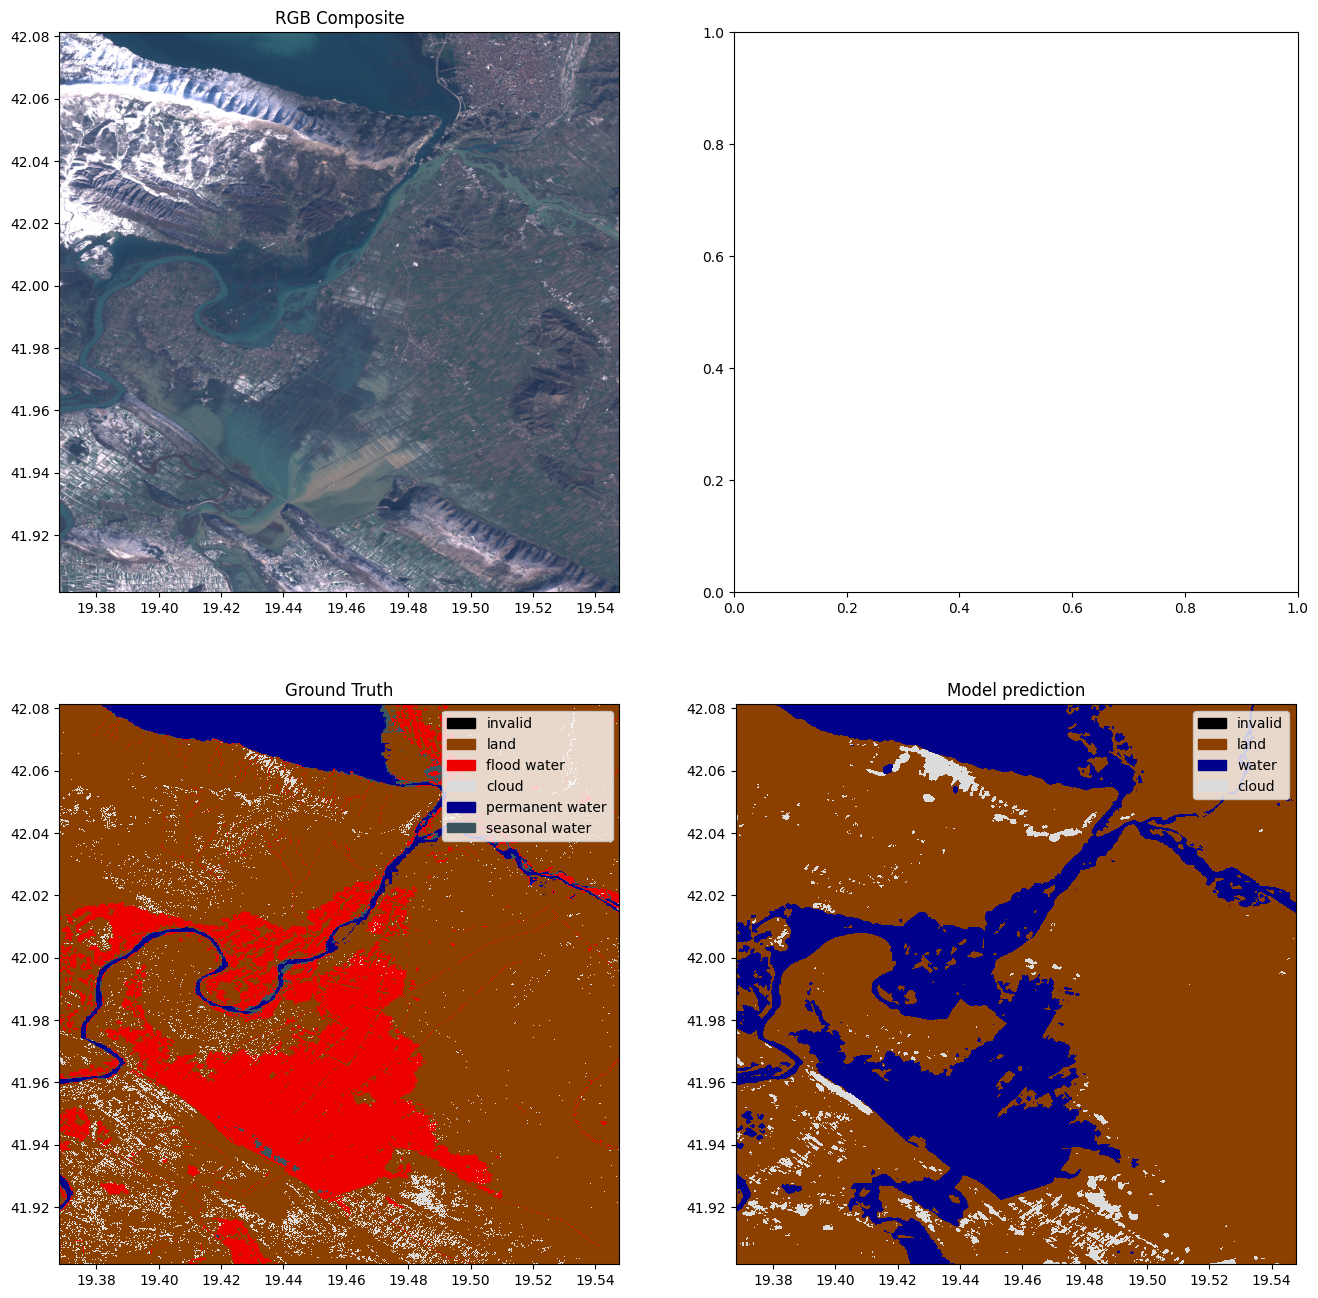

In [6]:
# from ml4floods.models.model_setup import get_channel_configuration_bands
from models.inference import get_channel_configuration_bands
import os
import rasterio.windows

#data prepared by the Janitors
cache_folder = "/mnt/d/Flooding/worldfloods_v1_0/tiffs_for_inference"
os.makedirs(cache_folder, exist_ok=True)

channel_configuration = config.model_params.hyperparameters.channel_configuration
 
window = rasterio.windows.Window(col_off=1543, row_off=247, 
                                 width=2000, height=2000)
tiff_s2, channels = "gs://ml4cc_data_lake/2_PROD/1_Staging/WorldFloods/S2/EMSR501/AOI01/EMSR501_AOI01_DEL_MONIT01_r1_v1.tif", get_channel_configuration_bands(config.model_params.hyperparameters.channel_configuration)

torch_inputs, torch_targets, torch_permanent_water, transform = read_inference_pair(tiff_s2, folder_ground_truth="/GT/V_1_1/", 
                                                                                    window=window, 
                                                                                    return_ground_truth=True, channels=channels,
                                                                                    folder_permanent_water="/JRC/",
                                                                                    cache_folder=cache_folder)

outputs = inference_function(torch_inputs) # (batch_size, num_classes, h, w)
prediction = torch.argmax(outputs, dim=1).long() # (batch_size, h, w)
plot_inference_set(torch_inputs, torch_targets, prediction, torch_permanent_water, transform,
                   channel_configuration=channel_configuration)

### Bonus: vectorise the water masks and plot them

In the code bellow `data_out` is a `GeoDataFrame` object. You can save it as a shapefile with [`save_file`](https://geopandas.org/docs/user_guide/io.html).

Channel Configuration: bgri
Available Configurations: dict_keys(['all', 'rgb', 'swirnirred', 'bgr', 'bgri', 'riswir', 'bgriswir', 'bgriswirs', 'l89s2', 'sub_20', 'hyperscout2'])


(74, 2)

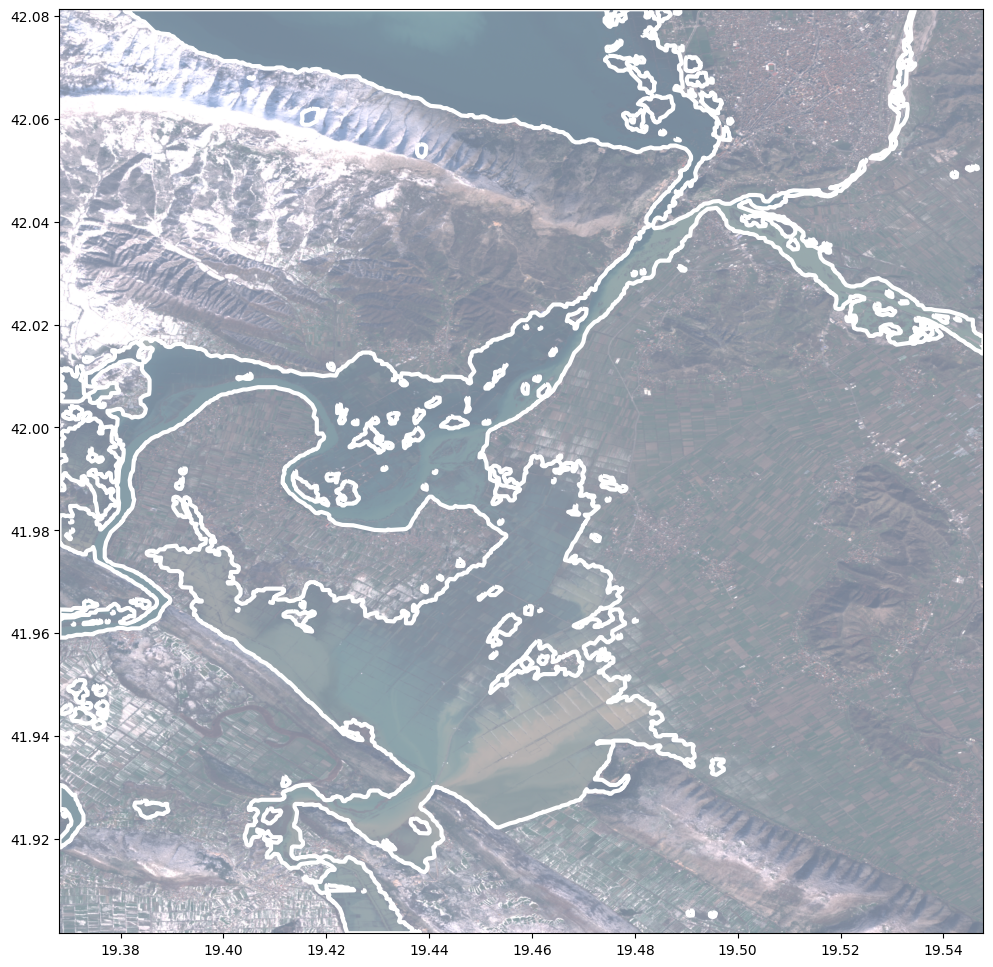

In [7]:
from ml4floods.models import postprocess
from ml4floods.visualization import plot_utils
import geopandas as gpd
from models.visualization import plot_s2_rbg_image

prob_water_mask = outputs[0,1].cpu().numpy()
binary_water_mask = prob_water_mask>.5

geoms_polygons = postprocess.get_water_polygons(binary_water_mask, transform=transform)

data_out = gpd.GeoDataFrame({"geometry": geoms_polygons, "id": np.arange(len(geoms_polygons))})
fig, ax = plt.subplots(1,1, figsize=(12, 12))
data_out.plot("id",legend=False,categorical=True,ax=ax,facecolor="None",edgecolor="1",linewidth=3)
print(f"Channel Configuration: {channel_configuration}")
print(f"Available Configurations: {CHANNELS_CONFIGURATIONS.keys()}")
plot_utils.plot_s2_rbg_image(torch_inputs[0].cpu().numpy(), transform=transform, ax=ax, alpha=.6,
                            channel_configuration=channel_configuration)

data_out.shape

In [ ]:
import rasterio
import numpy as np
from rasterio import plot as rasterioplt
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.patches as mpatches

from typing import Optional, Tuple, Union

import torch
from ml4floods.data.worldfloods.configs import BANDS_S2, CHANNELS_CONFIGURATIONS
from models.visualization import download_tiff
import os

def read_inference_image(tiff_inputs: str,
                         window: Optional[Union[rasterio.windows.Window, Tuple[slice, slice]]] = None,
                         channels: Optional[list] = None) -> Tuple[torch.Tensor, rasterio.Affine]:
    """
    Reads an image from a local .tif file and returns it as a Tensor with its transform.
    
    Args:
        tiff_inputs: Path to the .tif file.
        window: Optional window to crop the image.
        channels: List of channels to read from the image.
    
    Returns:
        torch_inputs: Input Tensor ready for inference.
        transform: Transform for geospatial plotting.
    """
    with rasterio.open(tiff_inputs, "r") as rst:
        inputs = rst.read((np.array(channels) + 1).tolist(), window=window)
        # Shifted transform based on the given window (used for plotting)
        transform = rst.transform if window is None else rasterio.windows.transform(window, rst.transform)
        torch_inputs = torch.Tensor(inputs.astype(np.float32)).unsqueeze(0)
    
    return torch_inputs, transform

# COLORS_WORLDFLOODS = np.array([[0, 0, 0], # invalid
#                                [139, 64, 0], # land
#                                [0, 0, 139], # water
#                                [220, 220, 220]], # cloud
#                               dtype=np.float32) / 255

# INTERPRETATION_WORLDFLOODS = ["invalid", "land", "water", "cloud"]

# def get_cmap_norm_colors(color_array, interpretation_array):
#     cmap_categorical = colors.ListedColormap(color_array)
#     norm_categorical = colors.Normalize(vmin=-.5,
#                                         vmax=color_array.shape[0]-.5)
#     patches = []
#     for c, interp in zip(color_array, interpretation_array):
#         patches.append(mpatches.Patch(color=c, label=interp))
    
#     return cmap_categorical, norm_categorical, patches

def plot_inference_set_file_dir(inputs: torch.Tensor, predictions: torch.Tensor, transform: rasterio.Affine, 
                       channel_configuration: str) -> None:
    """
    Plots inputs and predictions into a 2-panel visualization.
    
    Args:
        inputs: Input Tensor (1, C, H, W).
        predictions: Predictions output by the model (softmax, argmax already applied).
        transform: Transform for geospatial visualization.
        channel_configuration: Channel configuration for the input image.
    """
    fig, ax = plt.subplots(1, 2, figsize=(16, 8))
    
    inputs_show = inputs.cpu().numpy().squeeze()
    prediction_show = (predictions + 1).cpu().numpy().astype(float)
    
    # Prepare colormaps for predictions
    cmap_preds, norm_preds, patches_preds = get_cmap_norm_colors(COLORS_WORLDFLOODS, INTERPRETATION_WORLDFLOODS)
    
    # Display RGB Composite if available
    band_names_current_image = [BANDS_S2[iband] for iband in CHANNELS_CONFIGURATIONS[channel_configuration]]
    if all(b in band_names_current_image for b in ["B4", "B3", "B2"]):
        bands = [band_names_current_image.index(b) for b in ["B4", "B3", "B2"]]
        rgb = np.clip(inputs_show[bands, :, :] / 3000.0, 0, 1)
        rasterioplt.show(rgb, transform=transform, ax=ax[0])
        ax[0].set_title("RGB Composite")
    else:
        print("Can't show RGB Composite image: lacks required bands")
    
    # Display predictions
    rasterioplt.show(prediction_show, transform=transform, ax=ax[1], cmap=cmap_preds, norm=norm_preds, 
                     interpolation="nearest")
    ax[1].set_title("Model Prediction")
    ax[1].legend(handles=patches_preds, loc="upper right")


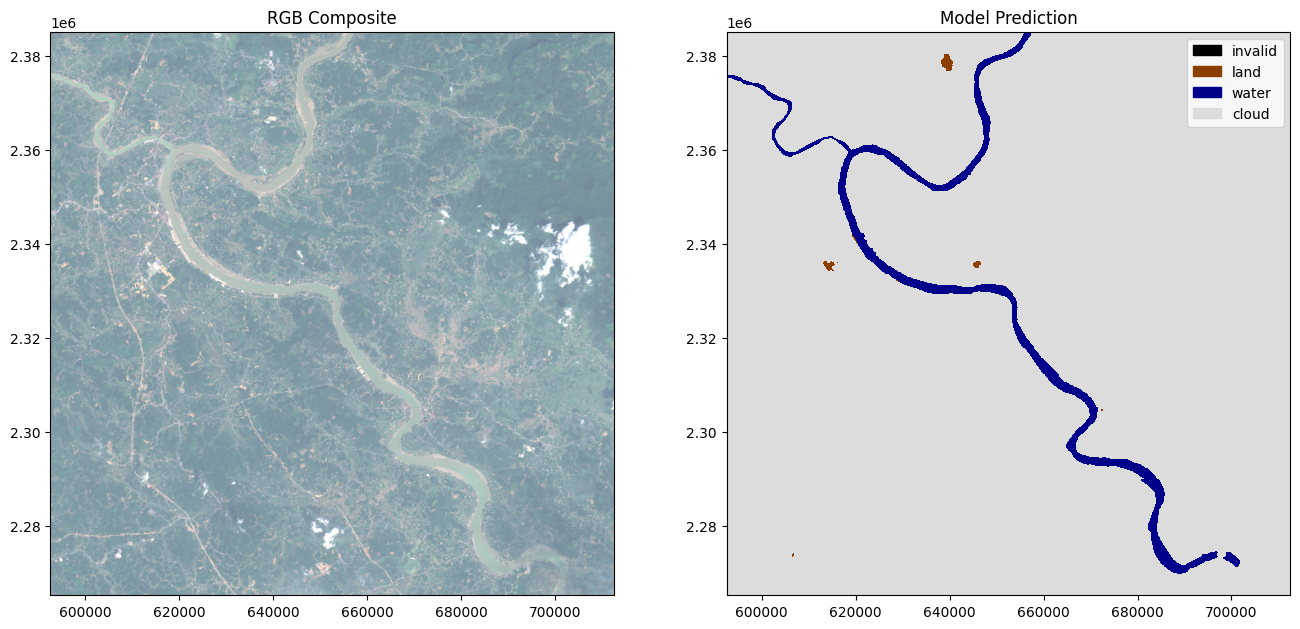

In [ ]:
from models.inference import get_channel_configuration_bands
import rasterio
import rasterio.windows

# Đường dẫn tới file .tif
# tiff_path = "/home/trongan93/thoailt/code/swrnet/T48QWJ_20240924T032521.tif"
tiff_path = "/mnt/d/Flooding/worldfloods_v1_0/tiffs_for_inference/S2/EMSR501_AOI01_DEL_MONIT01_r1_v1.tif"

# Cấu hình kênh từ config
channel_configuration = config.model_params.hyperparameters.channel_configuration
channels = get_channel_configuration_bands(channel_configuration)  # Lấy các kênh từ hàm

# Định nghĩa cửa sổ (window) để cắt ảnh
window = rasterio.windows.Window(col_off=1543, row_off=247, width=2000, height=2000)

# Đọc ảnh từ file .tif
torch_inputs, transform = read_inference_image(tiff_path, window=window, channels=channels)

# Thực hiện inference
outputs = inference_function(torch_inputs)  # (batch_size, num_classes, h, w)
prediction = torch.argmax(outputs, dim=1).long()  # (batch_size, h, w)

# Hiển thị kết quả
plot_inference_set_file_dir(torch_inputs, prediction, transform, channel_configuration=channel_configuration)


Channel Configuration: bgri
Available Configurations: dict_keys(['all', 'rgb', 'swirnirred', 'bgr', 'bgri', 'riswir', 'bgriswir', 'bgriswirs', 'l89s2', 'sub_20', 'hyperscout2'])


(2, 2)

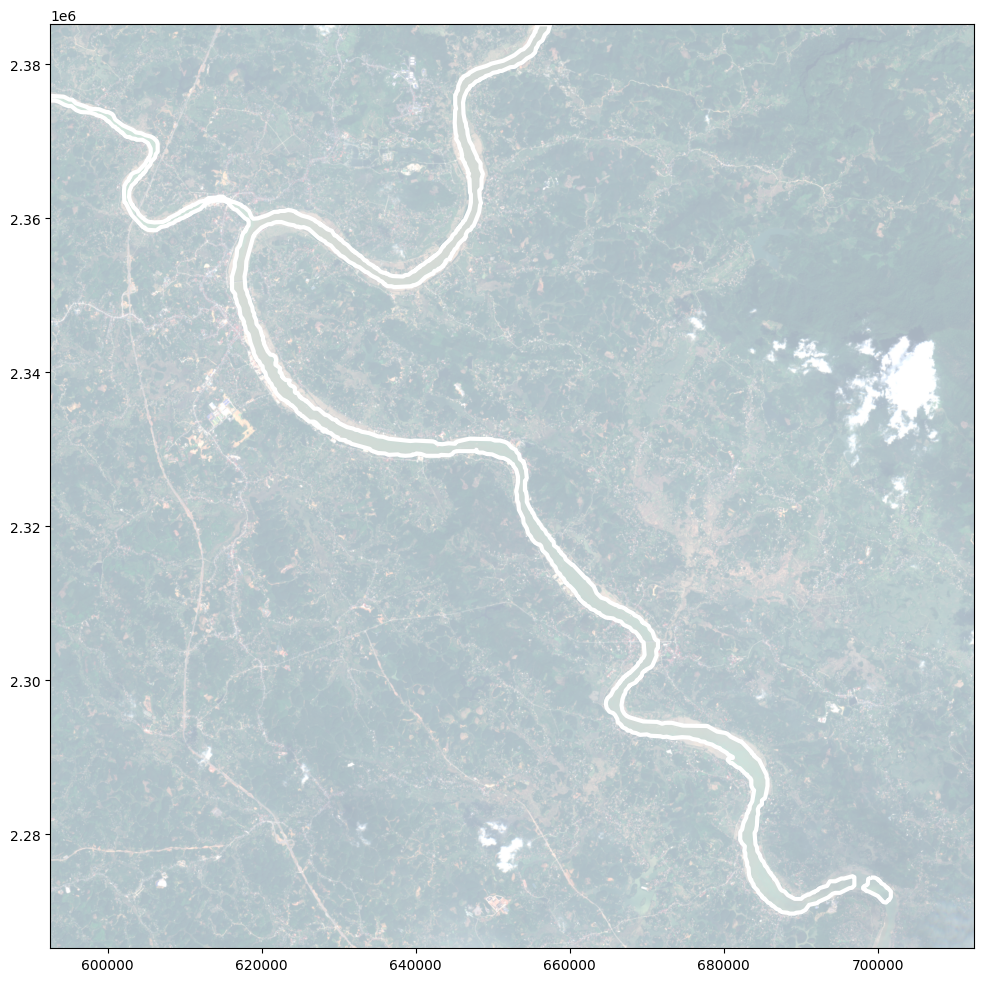

In [10]:
from ml4floods.models import postprocess
from ml4floods.visualization import plot_utils
import geopandas as gpd
from models.visualization import plot_s2_rbg_image

prob_water_mask = outputs[0,1].cpu().numpy()
binary_water_mask = prob_water_mask>.5

geoms_polygons = postprocess.get_water_polygons(binary_water_mask, transform=transform)

data_out = gpd.GeoDataFrame({"geometry": geoms_polygons, "id": np.arange(len(geoms_polygons))})
fig, ax = plt.subplots(1,1, figsize=(12, 12))
data_out.plot("id",legend=False,categorical=True,ax=ax,facecolor="None",edgecolor="1",linewidth=3)
print(f"Channel Configuration: {channel_configuration}")
print(f"Available Configurations: {CHANNELS_CONFIGURATIONS.keys()}")
plot_utils.plot_s2_rbg_image(torch_inputs[0].cpu().numpy(), transform=transform, ax=ax, alpha=.6,
                            channel_configuration=channel_configuration)

data_out.shape